# Data Engineering & EDA Workshop

This notebook demonstrates an end-to-end data engineering workflow using a cloud PostgreSQL database, Python, Pandas, and data visualization. The project includes data collection, cleaning, transformation, feature engineering, scaling, exploratory data analysis, and visualization.

In [1]:
import pandas as pd
import psycopg2
from faker import Faker
import random
from datetime import date
import os
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler

## 1. Data Collection

The employee dataset is synthetically generated using Python and the Faker library. The data includes employee names, IT-related job positions, start dates between 2015 and 2024, and salaries ranging from $60,000 to $200,000.

The generated employee records will be stored in a cloud PostgreSQL database hosted on Neon. Python will then connect to the database using psycopg2, and the data will be loaded into a Pandas DataFrame for analysis.

In [2]:
class EmployeeDataGenerator:
    """Generate synthetic employee records for the project."""

    def __init__(self):
        self.fake = Faker()

        self.positions = [
            "Software Developer",
            "Data Analyst",
            "Data Engineer",
            "Database Administrator",
            "Network Engineer",
            "Cybersecurity Analyst",
            "Cloud Engineer",
            "Systems Administrator"
        ]

    def generate_employees(self, number_of_employees=50):
        """Generate and return a list of employee records."""

        employees = []

        for employee_id in range(1, number_of_employees + 1):
            employee = (
                employee_id,
                self.fake.name(),
                random.choice(self.positions),
                self.fake.date_between(
                    start_date=date(2015, 1, 1),
                    end_date=date(2024, 12, 31)
                ),
                random.randint(60000, 200000)
            )

            employees.append(employee)

        return employees


# Create the generator object and generate 50 employees
employee_generator = EmployeeDataGenerator()
employees = employee_generator.generate_employees(50)

In [3]:
# Check that 50 employees were generated
print("Number of employees:", len(employees))

# Display the first generated employee
print("\nFirst employee:")
print(employees[0])

Number of employees: 50

First employee:
(1, 'Michael Nelson', 'Cybersecurity Analyst', datetime.date(2016, 3, 15), 196029)


In [4]:
# Load variables stored in the .env file
load_dotenv()


class EmployeeDatabase:
    """Manage PostgreSQL database operations for employee data."""

    def __init__(self):
        self.database_url = os.getenv("DATABASE_URL")

        if not self.database_url:
            raise ValueError(
                "DATABASE_URL was not found in the environment variables."
            )

    def test_connection(self):
        """Test the PostgreSQL database connection."""

        connection = psycopg2.connect(self.database_url)
        connection.close()

        print("Connected to Neon PostgreSQL successfully!")

    def insert_employees(self, employees):
        """Insert employee records into the employees table."""

        insert_query = """
        INSERT INTO employees (
            employee_id,
            name,
            position,
            start_date,
            salary
        )
        VALUES (%s, %s, %s, %s, %s)
        ON CONFLICT (employee_id) DO NOTHING;
        """

        connection = psycopg2.connect(self.database_url)
        cursor = connection.cursor()

        cursor.executemany(insert_query, employees)
        connection.commit()

        cursor.close()
        connection.close()

        print(f"{len(employees)} employees processed successfully!")

    def load_employees(self):
        """Load employee records from PostgreSQL into a DataFrame."""

        connection = psycopg2.connect(self.database_url)

        query = "SELECT * FROM employees;"
        employee_df = pd.read_sql(query, connection)

        connection.close()

        return employee_df


# Create one database object for the notebook
employee_database = EmployeeDatabase()

print("Database configuration loaded successfully!")

Database configuration loaded successfully!


In [5]:
# Test the database connection using the EmployeeDatabase object
employee_database.test_connection()

Connected to Neon PostgreSQL successfully!


In [6]:
# Insert the generated employees using the EmployeeDatabase object
employee_database.insert_employees(employees)

50 employees processed successfully!


In [7]:
# Load employee data from PostgreSQL using the EmployeeDatabase object
df = employee_database.load_employees()

# Display the first five rows
df.head()

C:\Users\sybun\AppData\Local\Temp\ipykernel_26632\1798762372.py:56: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  employee_df = pd.read_sql(query, connection)


,employee_id,name,position,start_date,salary
0,1,Melissa Vaughan,Software Developer,2024-03-05,186460
1,2,Mark Tran,Network Engineer,2024-04-23,164559
2,3,Charles Potts,Database Administrator,2019-02-26,72659
3,4,Blake Allen,Cybersecurity Analyst,2016-06-24,78156
4,5,Judith Sharp,Network Engineer,2016-11-15,165792


## 2. Data Cleaning

Before analyzing the employee data, the dataset will be inspected for missing values, incorrect data types, duplicate records, and other potential data quality issues.

In [8]:
class EmployeeAnalyzer:
    """Handle employee data cleaning, transformation, and analysis."""

    def __init__(self, df):
        self.df = df.copy()

    def inspect_data(self):
        """Display information about the employee DataFrame."""
        self.df.info()

    def check_missing_values(self):
        """Return the number of missing values in each column."""
        return self.df.isnull().sum()

    def check_duplicates(self):
        """Return the number of duplicate rows."""
        return self.df.duplicated().sum()

    def get_statistics(self):
        """Return descriptive statistics for numeric columns."""
        return self.df.describe()

    def engineer_features(self):
        """Create employee start-year and years-of-service features."""

        self.df["start_date"] = pd.to_datetime(self.df["start_date"])
        self.df["start_year"] = self.df["start_date"].dt.year
        self.df["years_of_service"] = 2024 - self.df["start_year"]

        return self.df

    def scale_salary(self):
        """Standardize salary values and create a salary_scaled column."""

        scaler = StandardScaler()

        self.df["salary_scaled"] = scaler.fit_transform(
            self.df[["salary"]]
        )

        return self.df

    def create_departments(self):
        """Create department information for advanced analysis."""

        departments = pd.DataFrame({
            "department_id": [1, 2, 3, 4],
            "department": [
                "Software Development",
                "Data & Analytics",
                "Infrastructure",
                "Cybersecurity"
            ],
            "location": [
                "Toronto",
                "Kitchener",
                "Waterloo",
                "Toronto"
            ],
            "budget": [
                1500000,
                1200000,
                1000000,
                900000
            ]
        })

        return departments

    def assign_departments(self):
        """Assign each employee to a department based on job position."""

        position_to_department = {
            "Software Developer": 1,
            "Data Analyst": 2,
            "Data Engineer": 2,
            "Database Administrator": 3,
            "Network Engineer": 3,
            "Cloud Engineer": 3,
            "Systems Administrator": 3,
            "Cybersecurity Analyst": 4
        }

        self.df["department_id"] = self.df["position"].map(
            position_to_department
        )

        return self.df

    def merge_departments(self, departments):
        """Merge employee data with department information."""

        merged_df = pd.merge(
            self.df,
            departments,
            on="department_id",
            how="left"
        )

        return merged_df

In [9]:
# Create an EmployeeAnalyzer object
analyzer = EmployeeAnalyzer(df)

# Inspect the employee data
analyzer.inspect_data()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   employee_id  50 non-null     int64 
 1   name         50 non-null     str   
 2   position     50 non-null     str   
 3   start_date   50 non-null     object
 4   salary       50 non-null     int64 
dtypes: int64(2), object(1), str(2)
memory usage: 2.1+ KB


In [10]:
# Check each column for missing values using the EmployeeAnalyzer object
analyzer.check_missing_values()

employee_id    0
name           0
position       0
start_date     0
salary         0
dtype: int64

In [11]:
# Check for duplicate rows using the EmployeeAnalyzer object
print("Number of duplicate rows:", analyzer.check_duplicates())

Number of duplicate rows: 0


In [12]:
# Display descriptive statistics using the EmployeeAnalyzer object
analyzer.get_statistics()

,employee_id,salary
count,50.00000,50.000000
mean,25.50000,125612.960000
std,14.57738,39101.012501
min,1.00000,63271.000000
25%,13.25000,95587.000000
50%,25.50000,116160.000000
75%,37.75000,151568.250000
max,50.00000,198532.000000


## 3. Data Transformation & Feature Engineering

The employee data is transformed by extracting the employee's start year from the start date. A new feature called `years_of_service` is also created to represent how many years each employee has worked at the company. These derived features will make the data easier to analyze and visualize.

In [13]:
# Apply feature engineering using the EmployeeAnalyzer object
df = analyzer.engineer_features()

# Display the updated DataFrame
df.head()

,employee_id,name,position,start_date,salary,start_year,years_of_service
0,1,Melissa Vaughan,Software Developer,2024-03-05,186460,2024,0
1,2,Mark Tran,Network Engineer,2024-04-23,164559,2024,0
2,3,Charles Potts,Database Administrator,2019-02-26,72659,2019,5
3,4,Blake Allen,Cybersecurity Analyst,2016-06-24,78156,2016,8
4,5,Judith Sharp,Network Engineer,2016-11-15,165792,2016,8


## 4. Scaling

Salary is a numeric feature with relatively large values. Standardization is applied to transform salary values so they are measured relative to the mean and standard deviation. This creates a new `salary_scaled` column while preserving the original salary values.

In [14]:
# Scale salary using the EmployeeAnalyzer object
df = analyzer.scale_salary()

# Display the original and scaled salary values
df[["salary", "salary_scaled"]].head()

,salary,salary_scaled
0,186460,1.571949
1,164559,1.006149
2,72659,-1.368036
3,78156,-1.226024
4,165792,1.038003


## 5. Visualization 1: Average Salary by Position and Start Year

This visualization compares the average employee salary across different IT positions and start years. Grouping the data by position and year helps identify differences in salary across job roles and hiring periods.

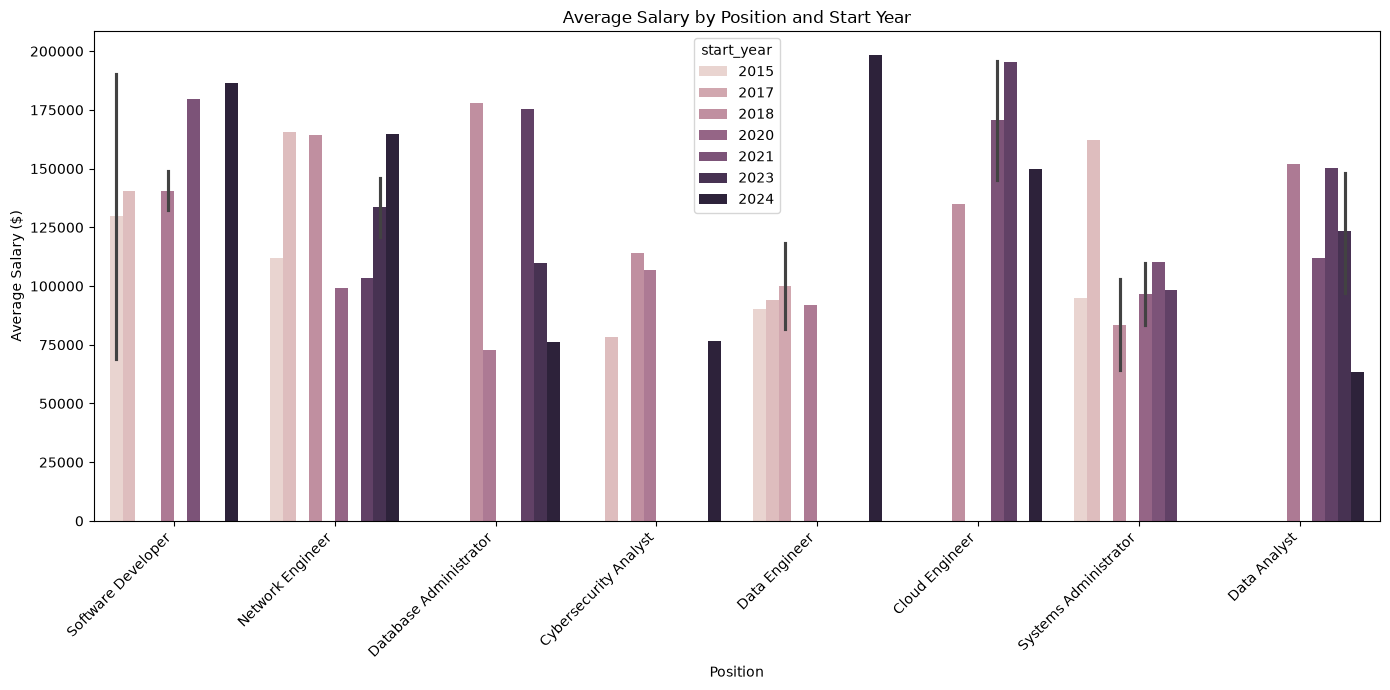

In [15]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create a grouped bar chart of average salary by position and start year
plt.figure(figsize=(14, 7))

sns.barplot(
    data=df,
    x="position",
    y="salary",
    hue="start_year",
    estimator="mean"
)

# Add labels and title
plt.title("Average Salary by Position and Start Year")
plt.xlabel("Position")
plt.ylabel("Average Salary ($)")

# Rotate job titles so they are easier to read
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 6. Visualization 2: Department and Salary Analysis

To create a more complex dataset, additional department information will be generated and joined with the employee data. This will allow salary patterns to be analyzed across both job positions and departments.

In [16]:
# Create department data using the EmployeeAnalyzer object
departments = analyzer.create_departments()

# Display the department data
departments

,department_id,department,location,budget
0,1,Software Development,Toronto,1500000
1,2,Data & Analytics,Kitchener,1200000
2,3,Infrastructure,Waterloo,1000000
3,4,Cybersecurity,Toronto,900000


In [17]:
# Assign employees to departments using the EmployeeAnalyzer object
df = analyzer.assign_departments()

# Display the new department assignments
df[["name", "position", "department_id"]].head()

,name,position,department_id
0,Melissa Vaughan,Software Developer,1
1,Mark Tran,Network Engineer,3
2,Charles Potts,Database Administrator,3
3,Blake Allen,Cybersecurity Analyst,4
4,Judith Sharp,Network Engineer,3


In [18]:
# Merge employee and department data using the EmployeeAnalyzer object
merged_df = analyzer.merge_departments(departments)

# Display part of the combined dataset
merged_df[
    ["name", "position", "department", "location", "salary"]
].head()

,name,position,department,location,salary
0,Melissa Vaughan,Software Developer,Software Development,Toronto,186460
1,Mark Tran,Network Engineer,Infrastructure,Waterloo,164559
2,Charles Potts,Database Administrator,Infrastructure,Waterloo,72659
3,Blake Allen,Cybersecurity Analyst,Cybersecurity,Toronto,78156
4,Judith Sharp,Network Engineer,Infrastructure,Waterloo,165792


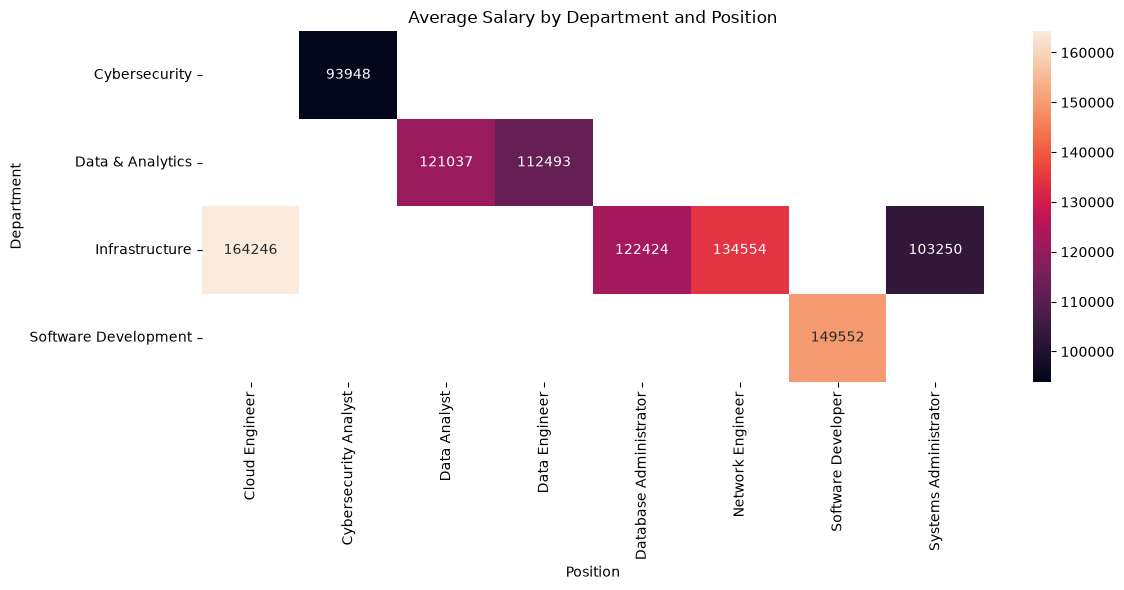

In [19]:
# Calculate the average salary for each department and position
salary_heatmap = merged_df.pivot_table(
    values="salary",
    index="department",
    columns="position",
    aggfunc="mean"
)

# Create the heatmap
plt.figure(figsize=(12, 6))

sns.heatmap(
    salary_heatmap,
    annot=True,
    fmt=".0f"
)

plt.title("Average Salary by Department and Position")
plt.xlabel("Position")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

## 7. Insights & Conclusions

### Visualization 1: Average Salary by Position and Start Year

The grouped bar chart shows noticeable differences in average salary across IT positions and start years. Cloud Engineers and Software Developers show some of the higher salaries in the dataset, while Cybersecurity Analysts generally show lower salaries. Salaries also vary considerably by start year within several positions. Because the dataset contains only 50 randomly generated employees, some position and year combinations have few or no employees, which explains the gaps in the chart.

### Visualization 2: Department and Position Salary Analysis

The heatmap shows differences in average salary across departments and positions. Cloud Engineers in the Infrastructure department have the highest average salary at approximately 164,246 USD, followed by Software Developers in the Software Development department at approximately 149,552 USD. Cybersecurity Analysts have the lowest average salary at approximately 93,948 USD. The visualization also clearly shows how each IT position is associated with its assigned department.

### Conclusion

This project demonstrated an end-to-end data engineering workflow. Synthetic employee data was generated with Python, stored in a cloud PostgreSQL database, retrieved using psycopg2 and Pandas, cleaned and transformed, and used to create new features. Salary data was also standardized, and an additional department dataset was joined with the employee data to support more advanced analysis and visualization. The workflow was refactored from its inital design using object-oriented programming through the EmployeeDataGenerator, EmployeeDatabase, and EmployeeAnalyzer classes, which organize data generation, database operations, and data analysis into separate responsibilities.